# **Exploratory Data Analysis**

#### The goal of this analysis is to understand the structure of the MovieLens dataset before using it in my movie recommendation system. This will give a better overview of the data used.

I will be focusing on:
- Dataset size and structure
- Genre distribution
- Rating distribution
- User activity
- Movie popularity
---

### Loading the dataset

The MovieLens dataset contains several files, for this analysis the `movies.csv` and `ratings.csv` files are used.

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

movies = pd.read_csv("ml-latest/movies.csv")
ratings = pd.read_csv("ml-latest/ratings.csv")

print("Movies:", movies.shape)
print("Ratings:", ratings.shape)

Movies: (86537, 3)
Ratings: (33832162, 4)


The dataset contains a large number of movies and ratings, which means that my recommendation system needs to be able to run fast while also handling large amounts of data.

---

### Dataset Overview

In [7]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [8]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,1225734739
1,1,110,4.0,1225865086
2,1,158,4.0,1225733503
3,1,260,4.5,1225735204
4,1,356,5.0,1225735119


The *movies* dataset contains 3 columns:
- movieId
- title
- genres

The *ratings* dataset contains 4 columns:
- userId
- movieId
- rating
- timestamp

To be able to analyse movies based on ratings, the column *movieId* is used because it links the two datasets.

---

### Genre Distribution

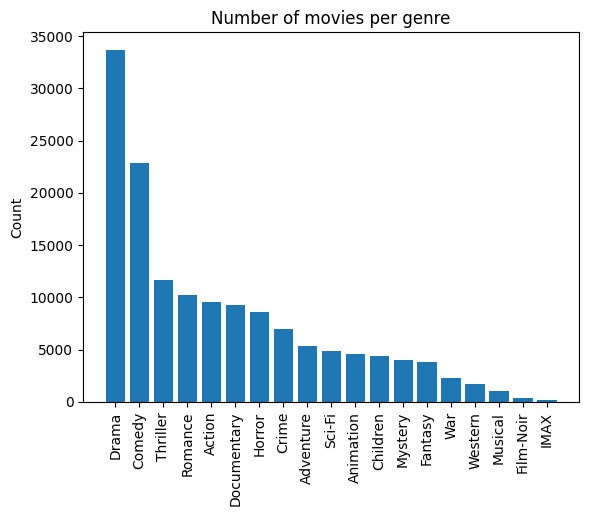

In [9]:
from recommendation_system import genres

genre_counts = genres.sum().sort_values(ascending=False)

plt.figure()
plt.bar(genre_counts.index, genre_counts.values)
plt.title("Number of movies per genre")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

The dataset contains 20 genres, with Drama, Comedy and Thriller being the most common ones. Though I noticed quickly while going through the dataset that there was one listed as *"(no genres listed)"*. 

In [10]:
genres.sum().sort_values(ascending=False)

Drama          33681
Comedy         22830
Thriller       11675
Romance        10172
Action          9563
Documentary     9283
Horror          8570
Crime           6917
Adventure       5349
Sci-Fi          4850
Animation       4579
Children        4367
Mystery         3972
Fantasy         3821
War             2301
Western         1690
Musical         1059
Film-Noir        354
IMAX             195
dtype: int64

While looking at the amount of movies in each genre, you can see that the *(no genres listed)* has 7060 movies linked to it. That means 7060 movies have no genres listed. It's a lot of movies but compared to the total amount of movies in the dataset, it won't affect the recommendation system. It's good to be aware of it though.

---

### Rating Distribution

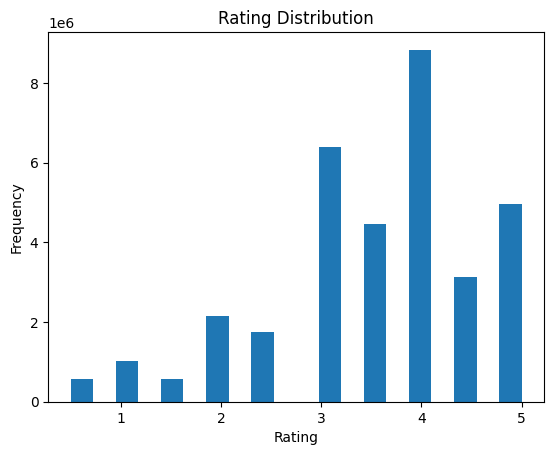

In [11]:
plt.figure()
plt.hist(ratings["rating"], bins=20)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

Here you can see the distribution of ratings in the dataset. There are over 8 million 4-star ratings for example. In average the users tend to give relatively positive ratings. 
*This may affect rating-prediction models*

---

### Number of ratings per movie

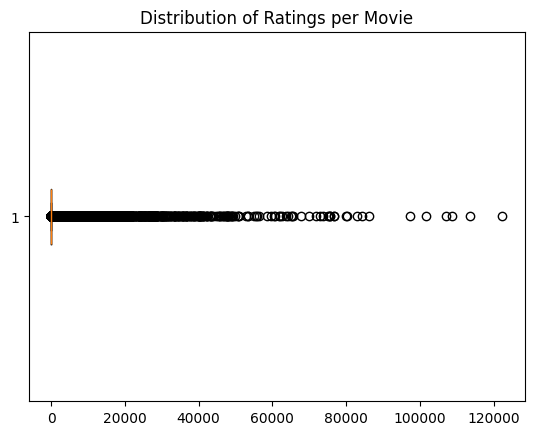

In [12]:
ratings_per_movie = ratings.groupby("movieId").size()

plt.figure()
plt.boxplot(ratings_per_movie, vert=False)
plt.title("Distribution of Ratings per Movie")
plt.show()

From the boxplot we can observe that most movies have few ratings, and only a very small number of movies are highly popular. Since less popular movies (the majority) have limited rating information, it might reduce the quality of collaborative filtering approaches. This shows clearly with the median being marked extremely low.

I tried first to visualize the dataset with a histogram, but because it has a long-tail distribution everything gets squashed on the left. With a boxplot you can easier see the difference between movies and amount of ratings

---

### User Activity

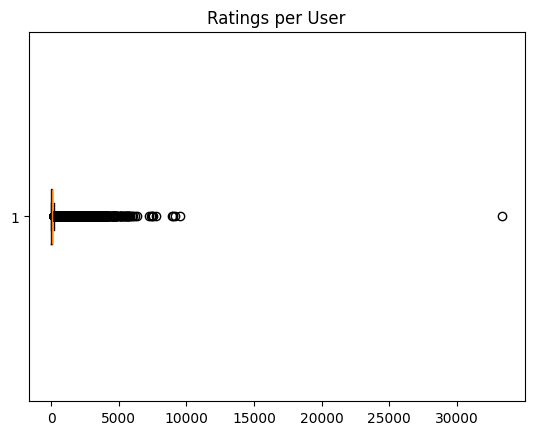

In [13]:
ratings_per_user = ratings.groupby("userId").size()

plt.figure()
plt.boxplot(ratings_per_user, vert=False)
plt.title("Ratings per User")
plt.show()

Similiar results as with the dataset above. The user activity varies significantly, most users rate few movies while only a small amount of users rate a much higher amount of movies. This as well can make collaborative filtering more challenging. This is important to know when building recommendation systems.

---

### Most Popular Movies

In [14]:
ratings_count = ratings.groupby("movieId").size()
top_movies = ratings_count.sort_values(ascending=False).head(10)
top_movies = top_movies.reset_index(name="rating_count")
top_movies = top_movies.merge(movies, on="movieId")
top_movies[["title", "rating_count"]]

,title,rating_count
0,"Shawshank Redemption, The (1994)",122296
1,Forrest Gump (1994),113581
2,Pulp Fiction (1994),108756
3,"Matrix, The (1999)",107056
4,"Silence of the Lambs, The (1991)",101802
5,Star Wars: Episode IV - A New Hope (1977),97202
6,Fight Club (1999),86207
7,Schindler's List (1993),84232
8,Jurassic Park (1993),83026
9,Star Wars: Episode V - The Empire Strikes Back...,80200


### Tags Analysis

In [15]:
tags = pd.read_csv("ml-latest/tags.csv")
print("Tags shape:", tags.shape)
tags.head()

Tags shape: (2328315, 4)


,userId,movieId,tag,timestamp
0,10,260,good vs evil,1430666558
1,10,260,Harrison Ford,1430666505
2,10,260,sci-fi,1430666538
3,14,1221,Al Pacino,1311600756
4,14,1221,mafia,1311600746


The `tags.csv` file contains 4 columns:
- **userId** - the user who applied the tag
- **movieId** - the movie being tagged
- **tag** - a free-text label (e.g. "mafia", "good vs evil")
- **timestamp** - when the tag was applied

In [19]:
tagged_movie_count = tags["movieId"].nunique()
total_movie_count = movies["movieId"].nunique()
percentage_coverage = 100 * tagged_movie_count / total_movie_count

print(f"Tagged movies: {tagged_movie_count} out of {total_movie_count} ({percentage_coverage:.1f}%)")
print(f"Total tag entries: {len(tags):,}")
print(f"Unique tag strings: {tags['tag'].nunique():,}")

Tagged movies: 53452 out of 86537 (61.8%)
Total tag entries: 2,328,315
Unique tag strings: 153,949


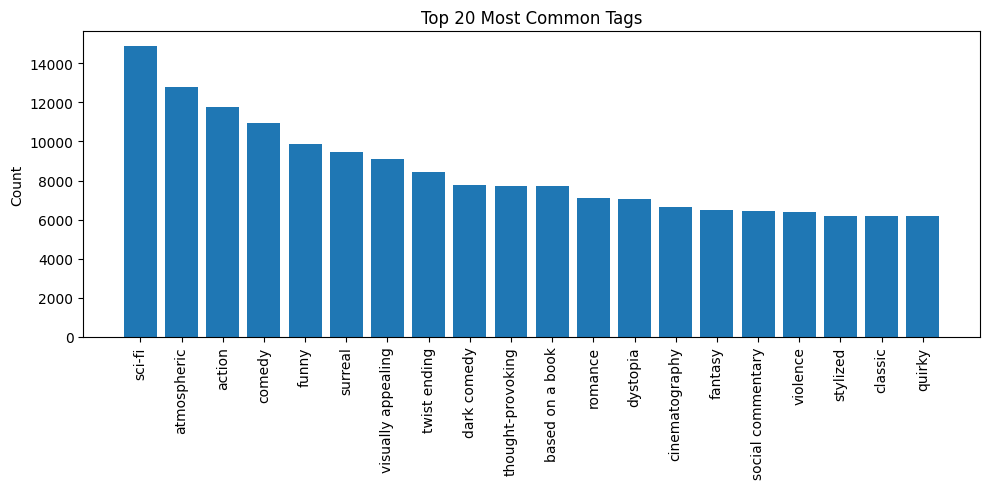

In [22]:
top_tags = tags["tag"].str.lower().value_counts().head(20)

plt.figure(figsize=(10, 5))
plt.bar(top_tags.index, top_tags.values)
plt.title("Top 20 Most Common Tags")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

The `tags.csv` file contains free-text labels that users have applied to movies, for example atmospheric, based on a book or sci-fi.
A few things stand out when looking at the data:

- Most movies have no tags at all, and most users have never tagged anything. Tagging is much less common than rating.
- Many popular tags like comedy or action just repeat what is already in the genres column, so they don't add much new information
- The same concept often appears under many different spellings (sci-fi, sci fi, scifi) which would make it harder to use in a model. Needs a lot of pre-processing to be able to use in a recommendation system.
- A large share of tags only appear once in the whole dataset, which only becomes noise since it cannot be linked to other movies.

Because of this, tags were not used in my recommendation system. Genre information covers all movies and was a more reliable choice. (Though, with correct handling and good pre-processing of the dataset, the tags can be a great complement with the genre dataset)

---

### Summary

From the exploratory analysis we can conclude:
- The dataset is large and sparse
- Genre information covers all movies, though 7060 have `(no genres listed)`. These are excluded from the recommendation system
- Ratings are generally positive (most between 3.0 and 4.5); this affects rating-prediction approaches
- Rating and tagging activity is heavily skewed: most movies have very few ratings and only around 60% of movies have tags. (However the number of tags per movie is still low on average, meaning many movies only have one or two tags)

My conclusion is that a genre-based similarity model using cosine similariy and KNN is an efficient and reasonable approach for my recommendation system